<a href="https://colab.research.google.com/github/ZavalaCatalina/InteligenciaComputacional/blob/main/Participacion19marzo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Participación - marzo 19
Aplicación de técnicas de preprocesamiento utilizando PyTorch.

##Carga y Partición del Dataset
sklearn para la carga y la división de los datos en proporciones 80/10/10 (entrenamiento, validación y prueba).

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import numpy as np

# Carga del dataset
x, y = fetch_california_housing(return_X_y=True, as_frame=True)

# Partición 80/10/10, 80% para train y  20% restante(val & test)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
# 10% val, 10% test
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# Conversión a tensores de PyTorch
X_train_t = torch.tensor(x_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(x_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(x_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

##Modelo con Preprocesamiento Integrado
Para evitar el data leakage, las estadísticas del StandardScaler (media y desviación estándar) y los límites para outliers con los datos de entrenamiento.

In [7]:
class HousingModel(nn.Module):
    def __init__(self, input_dim, train_data, hidden_layers=[64, 32]):
        super(HousingModel, self).__init__()

        # indices columnas (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Lat, Long)
        self.non_geo_indices = [0, 1, 2, 3, 4, 5]
        self.geo_indices = [6, 7]

        # calculo de parámetros para evitar data leakage
        train_non_geo = train_data[:, self.non_geo_indices]
        self.means = train_non_geo.mean(dim=0)
        self.stds = train_non_geo.std(dim=0)

        # Definición de capas
        layers = []
        in_features = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
        layers.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*layers)

# Outliers: clipping basado en el conjunto de entrenamiento. aplicar a todas excepto Latitude y Longitude
    def preprocess(self, x):
        x_processed = x.clone()
        for i in self.non_geo_indices:
            q1 = torch.quantile(x_processed[:, i], 0.25)
            q3 = torch.quantile(x_processed[:, i], 0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            x_processed[:, i] = torch.clamp(x_processed[:, i], lower, upper)

# Standard Scaling, con  medias/stds de entrenamiento
        x_processed[:, self.non_geo_indices] = (x_processed[:, self.non_geo_indices] - self.means) / (self.stds + 1e-8)

        return x_processed

    def forward(self, x):
        x = self.preprocess(x)
        return self.network(x)

##Entrenamiento de 3 Modelos
tres configuraciones de hiperparámetros (arquitectura de capas y tasa de aprendizaje).

In [8]:
def train_loop(model, X, y, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
    return loss.item()

# Configuración de experimentos/modelos
input_dim = X_train_t.shape[1]
configs = [
    {"hidden": [32, 16], "lr": 0.01},
    {"hidden": [64, 32], "lr": 0.005},
    {"hidden": [128, 64, 32], "lr": 0.001}
]

models = []
for i, config in enumerate(configs):
    m = HousingModel(input_dim, X_train_t, hidden_layers=config["hidden"])
    loss = train_loop(m, X_train_t, y_train_t, lr=config["lr"])
    models.append(m)
    print(f"Modelo {i+1} entrenado. Capas: {config['hidden']}, Loss final: {loss:.4f}")

Modelo 1 entrenado. Capas: [32, 16], Loss final: 0.7616
Modelo 2 entrenado. Capas: [64, 32], Loss final: 0.9345
Modelo 3 entrenado. Capas: [128, 64, 32], Loss final: 1.1011


##Evaluación del Mejor Modelo
Evaluacion del rendimiento utilizando el Error Absoluto Medio (MAE) en el conjunto de prueba

In [9]:
# mejor modelo
best_model = models[2]
best_model.eval()

with torch.no_grad():
    predictions = best_model(X_test_t)
    mae = torch.mean(torch.abs(predictions - y_test_t))
    mse = torch.mean((predictions - y_test_t)**2)

print(f"\nEvaluación del mejor modelo en Test:")
print(f"MAE: {mae.item():.4f}")
print(f"MSE: {mse.item():.4f}")


Evaluación del mejor modelo en Test:
MAE: 0.8102
MSE: 1.0709


##graficas comparativas

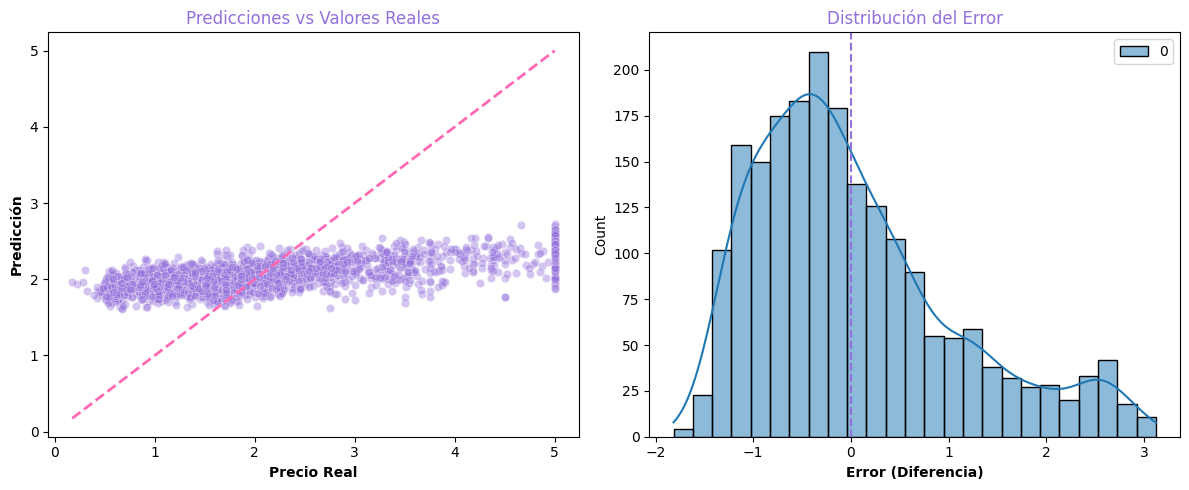

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


color_rosa = "#FF69B4" # HotPink
color_morado = "#9370DB" # MediumPurple

best_model.eval()
with torch.no_grad():
    preds = best_model(X_test_t).numpy()
    targets = y_test_t.numpy()

plt.figure(figsize=(12, 5))

# Gráfica de Dispersión
plt.subplot(1, 2, 1)
sns.scatterplot(x=targets.flatten(), y=preds.flatten(), color=color_morado, alpha=0.4)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], color=color_rosa, linestyle='--', lw=2)
plt.title('Predicciones vs Valores Reales', color=color_morado)
plt.xlabel('Precio Real', fontweight='bold')
plt.ylabel('Predicción', fontweight='bold')

# Histograma de Errores
plt.subplot(1, 2, 2)
error = targets - preds
sns.histplot(error, kde=True, color=color_rosa, line_kws={'color': color_morado})
plt.axvline(x=0, color=color_morado, linestyle='--')
plt.title('Distribución del Error', color=color_morado)
plt.xlabel('Error (Diferencia)', fontweight='bold')

plt.tight_layout()
plt.show()

En este proyecto se observa que el mejor modelo fue el Modelo 3, con una arquitectura de tres capas ocultas (128, 64 y 32 neuronas) y logró el menor error promedio en las predicciones. Al calcular las estadísticas de normalización solo con el conjunto de entrenamiento, no hubo data leakage, por lo que la evaluación fue buena respecto al desempeño.
Como se puede ver en las gráficas, dejar la latitud y longitud sin tocara ayudo a que el modelo entendiera la ubicación real sin perderse en los datos,la mayoría de los puntos en el gráfico de dispersión se agrupan cerca de la línea guía,a unque el MAE es bastante bajo y la mayoría de las predicciones siguen bien la línea diagonal, el histograma muestra que los errores son pequeños y están bien distribuidos.